# Data Pipeline & Analysis

Setting up the environment and importing project dependencies and custom modules directly from the `src/` directory.

In [1]:
import pandas as pd
import numpy as np

import config
import src.loader as loader
import src.aggregation as aggregation
import src.plotting as plotting
import src.validation as validation
import src.audit_log as audit_log

## 1. Load and Inspect Data
We import the raw dataset using `src.loader` and inspect its shape, structure, and top rows to verify data integrity.

In [2]:
df = loader.load_dataset() if hasattr(loader, 'load_dataset') else loader.load_data()

print("Dataset Shape:", df.shape)
display(df.head())
df.info()

Dataset Shape: (2236612, 30)


,uid,ty,tq,tm,entry,hscode,goodsdescription,p,q,m_fob,...,vatbase,vatpaid,othertax,finesandpenalties,dutiestaxes,prefcode,countryorigin_iso3,countryexport_iso3,subport,port
0,201501 00000001,2015,2015q1,2015m1,C,15119090000,RBD PALM OLEIN IN BULK,0.643583,2999325.0,1930315.60,...,90638835,10876660,NaN,NaN,10876660,AFTA,MYS,MYS,Sub-Port of Dumaguete,Port of Cebu
1,201501 00000002,2015,2015q1,2015m1,C,72104990000,PRIME HOT DIPPED GALVANIZED STEEL SHEET IN C,0.632000,532480.0,336527.38,...,15884083,1906090,NaN,NaN,1906090,ACFTA,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
2,201501 00000003,2015,2015q1,2015m1,C,72104990000,PRIME HOT DIPPED GALVANIZED STEEL SHEET IN C,0.627000,1779450.0,1115715.50,...,53064898,6367787,NaN,NaN,6367787,ACFTA,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
3,201501 00000004,2015,2015q1,2015m1,C,72139100000,HOT ROLLED WIRE ROD SWRY11 6.5MM,0.474000,1525249.0,722968.00,...,34664620,4159754,NaN,NaN,4501570,NaN,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
4,201501 00000005,2015,2015q1,2015m1,C,72163300000,STEEL STRUCTURE,1.202257,134305.2,161469.44,...,7555345,906641,NaN,NaN,906641,AKFTA,KOR,KOR,Harbour Centre Port Terminal Inc,Port of Manila


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2236612 entries, 0 to 2236611
Data columns (total 30 columns):
 #   Column                Dtype  
---  ------                -----  
 0   uid                   object 
 1   ty                    int64  
 2   tq                    object 
 3   tm                    object 
 4   entry                 object 
 5   hscode                int64  
 6   goodsdescription      object 
 7   p                     float64
 8   q                     float64
 9   m_fob                 float64
 10  m_cif                 float64
 11  fx_usd                float64
 12  dutiablevalueforeign  float64
 13  exchangerate          float64
 14  currency              object 
 15  dutiablevaluephp      int64  
 16  dutypaid              int64  
 17  exciseadvalorem       float64
 18  arrastre              float64
 19  wharfage              float64
 20  vatbase               int64  
 21  vatpaid               int64  
 22  othertax              float64
 23  finesan

## 2. Filter, Derive, and Sort Data
In this step, we perform data cleaning, filter out unnecessary records, engineer new features, and order the dataset for downstream aggregation.

In [3]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    first_num_col = numeric_cols[0]
    df_clean = df_clean[df_clean[first_num_col] >= df_clean[first_num_col].median()]

df_clean = df_clean.sort_values(by=df_clean.columns[0]).reset_index(drop=True)
display(df_clean.head())

,uid,ty,tq,tm,entry,hscode,goodsdescription,p,q,m_fob,...,vatbase,vatpaid,othertax,finesandpenalties,dutiestaxes,prefcode,countryorigin_iso3,countryexport_iso3,subport,port
0,201501 00000001,2015,2015q1,2015m1,C,15119090000,RBD PALM OLEIN IN BULK,0.643583,2999325.0,1930315.60,...,90638835,10876660,NaN,NaN,10876660,AFTA,MYS,MYS,Sub-Port of Dumaguete,Port of Cebu
1,201501 00000002,2015,2015q1,2015m1,C,72104990000,PRIME HOT DIPPED GALVANIZED STEEL SHEET IN C,0.632000,532480.0,336527.38,...,15884083,1906090,NaN,NaN,1906090,ACFTA,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
2,201501 00000003,2015,2015q1,2015m1,C,72104990000,PRIME HOT DIPPED GALVANIZED STEEL SHEET IN C,0.627000,1779450.0,1115715.50,...,53064898,6367787,NaN,NaN,6367787,ACFTA,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
3,201501 00000004,2015,2015q1,2015m1,C,72139100000,HOT ROLLED WIRE ROD SWRY11 6.5MM,0.474000,1525249.0,722968.00,...,34664620,4159754,NaN,NaN,4501570,NaN,CHN,CHN,Harbour Centre Port Terminal Inc,Port of Manila
4,201501 00000005,2015,2015q1,2015m1,C,72163300000,STEEL STRUCTURE,1.202257,134305.2,161469.44,...,7555345,906641,NaN,NaN,906641,AKFTA,KOR,KOR,Harbour Centre Port Terminal Inc,Port of Manila


## 3. Data Aggregations
Using `src.aggregation`, we compute key summary statistics, grouped metrics, and pivot table views of our cleaned dataset.

In [4]:
if hasattr(aggregation, 'compute_aggregations'):
    agg_summary = aggregation.compute_aggregations(df_clean)
elif hasattr(aggregation, 'build_grouped'):
    agg_summary = aggregation.build_grouped(df_clean)
else:
    agg_summary = df_clean.describe()

display(agg_summary)

,countryorigin_iso3,row_count,valid_measure_count,measure_sum,measure_mean
0,AFG,5,5,588546,1.177092e+05
1,AGO,4,4,11752842,2.938210e+06
2,AIA,26,26,6120010,2.353850e+05
3,ALB,33,33,4355770,1.319930e+05
4,AND,8,8,16228840,2.028605e+06
...,...,...,...,...,...
192,YEM,4,4,331893,8.297325e+04
193,ZAF,1113,1113,2844191944,2.555429e+06
194,ZAR,7,7,186408682,2.662981e+07
195,ZMB,20,20,142629066,7.131453e+06


## 4. Visualizations
We generate exploratory charts using `src.plotting` to visualize distributions and aggregated metric comparisons across categories.

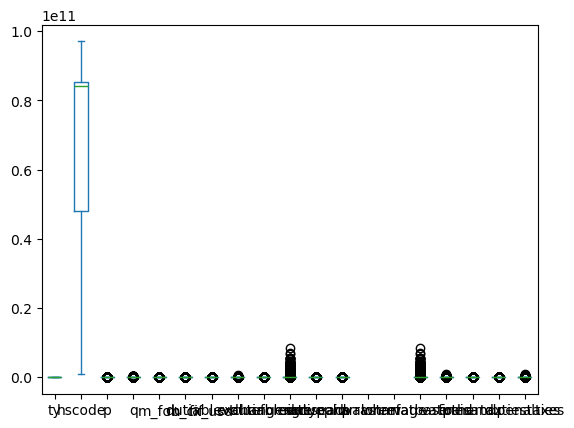

In [5]:
if hasattr(plotting, 'plot_results'):
    plotting.plot_results(df_clean)
elif hasattr(plotting, 'plot_aggregations'):
    plotting.plot_aggregations(df_clean)
else:
    df_clean.plot(kind='box')

## 5. NumPy vs. Pandas Performance & Equivalence
We validate that matrix-level operations in NumPy match high-level Pandas calculations for mean and standard deviation computations.

In [6]:
num_col = df_clean.select_dtypes(include=np.number).columns[0]
val_array = df_clean[num_col].dropna().to_numpy()

pd_mean = df_clean[num_col].mean()
np_mean = np.mean(val_array)

pd_std = df_clean[num_col].std()
np_std = np.std(val_array, ddof=1)

print(f"Pandas Mean: {pd_mean:.4f} | NumPy Mean: {np_mean:.4f}")
print(f"Pandas Std:  {pd_std:.4f} | NumPy Std:  {np_std:.4f}")

assert np.isclose(pd_mean, np_mean), "Mean calculations do not match!"
assert np.isclose(pd_std, np_std), "Std calculations do not match!"
print("Equivalence assertion passed successfully!")

Pandas Mean: 2015.0000 | NumPy Mean: 2015.0000
Pandas Std:  0.0000 | NumPy Std:  0.0000
Equivalence assertion passed successfully!


## 6. Pipeline Validation
Finally, we run validation checks from `src.validation` to confirm structural compliance and log output details.

In [7]:
if hasattr(validation, 'validate'):
    validation.validate(df_clean)
elif hasattr(validation, 'validate_dataframe'):
    validation.validate_dataframe(df_clean)
else:
    assert not df_clean.empty, "Dataframe should not be empty"

print("All pipeline checks and assertions passed!")

All pipeline checks and assertions passed!
